In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

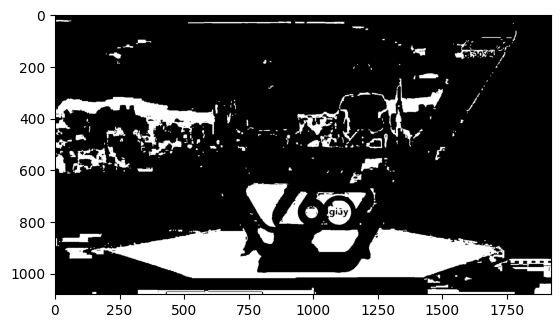

In [104]:

def masks_color(preprocessed_frame: np.ndarray) -> np.ndarray:
    lower_red1 = np.array([0, 20, 20])
    upper_red1 = np.array([3, 255, 200])
    lower_red2 = np.array([174, 20, 40])
    upper_red2 = np.array([179, 255, 205])
    
    mask_red = cv2.bitwise_or(
            cv2.inRange(preprocessed_frame, lower_red1, upper_red1),
            cv2.inRange(preprocessed_frame, lower_red2, upper_red2)
        )

    
    # Apply morphological opening to clean up the mask
    kernel_open = np.ones((3, 3), np.uint8)
    mask_combine = cv2.morphologyEx(mask_red, cv2.MORPH_OPEN, kernel_open)
    # area = cv2.countNonZero(mask_combine)
    # threshold = 20000
    # if area > threshold:
    #     return 1
    return mask_combine

def get_masked_image(id):
    image_bgr = cv2.imread(f'../segments/K01_V001/scene_{id:03}.jpg', cv2.IMREAD_COLOR)

    image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    masked = masks_color(image_hsv)
    return masked

masked = get_masked_image(15)
plt.imshow(masked, cmap='gray')
plt.show()

In [106]:
for id in range(15, 34):
    masked = get_masked_image(id)
    area = cv2.countNonZero(masked)
    print(f"Scene {id:03}: Red area = {area}")

Scene 015: Red area = 324439
Scene 016: Red area = 112661
Scene 017: Red area = 258589
Scene 018: Red area = 171660
Scene 019: Red area = 285553
Scene 020: Red area = 254865
Scene 021: Red area = 80730
Scene 022: Red area = 315148
Scene 023: Red area = 127238
Scene 024: Red area = 317897
Scene 025: Red area = 76072
Scene 026: Red area = 51369
Scene 027: Red area = 114190
Scene 028: Red area = 69741
Scene 029: Red area = 100807
Scene 030: Red area = 151501
Scene 031: Red area = 164367
Scene 032: Red area = 152021
Scene 033: Red area = 272230
